# Phân cụm K-Means (K=3) đếm điểm ESG của các ngân hàng

Tập lệnh này thực hiện thuật toán học máy K-Means Clustering trên dữ liệu (gồm 7 features) đã được gộp từ hai luồng trước:
1. Đọc dữ liệu đầu vào.
2. Làm sạch dữ liệu (Xóa các dòng rác có điểm 0).
3. Chuẩn hóa dữ liệu (Standardization).
4. Thực thi K-Means để chia ngân hàng thành 3 cụm.
5. Vẽ biểu đồ phân tán và xuất kết quả.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# =====================================================================
# CẤU HÌNH ĐƯỜNG DẪN 
# =====================================================================
PROJECT_ROOT = Path("D:/NCKH")
T3_DIR = PROJECT_ROOT / "Thread_3"

INPUT_FILE = T3_DIR / "Combined_Features_For_KMeans.xlsx"
OUTPUT_FILE = T3_DIR / "KMeans_Clustered_Results.xlsx"
PLOT_FILE = T3_DIR / "KMeans_Scatter_Plot.png"

# Thiết lập vẽ đồ thị đẹp hơn
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
# =====================================================================
# 1. LOAD DỮ LIỆU & LÀM SẠCH (DATA CLEANING)
# =====================================================================
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"❌ Không tìm thấy file đầu vào: {INPUT_FILE}. Vui lòng chạy file gộp luồng trước.")

df = pd.read_excel(INPUT_FILE)
print(f"Đã tải {len(df)} bản ghi ban đầu.")

# LÀM SẠCH BẮT BUỘC:
# Xóa dòng nếu Report_Score_X hoặc News_Score_Y_mean là 0 (hoặc xấp xỉ 0)
df_clean = df[(df['Report_Score_X'] != 0) & (df['News_Score_Y_mean'] != 0)].copy()

# Reset index sau khi drop rows
df_clean.reset_index(drop=True, inplace=True)

print(f"✅ Sau khi làm sạch (loại bỏ điểm 0): còn {len(df_clean)} bản ghi phù hợp.")
display(df_clean.head())

Đã tải 28 bản ghi ban đầu.
✅ Sau khi làm sạch (loại bỏ điểm 0): còn 26 bản ghi phù hợp.


,Year,Bank_Name,Report_Score_X,News_Score_Y_mean,Delta_Gap,E_tfidf,S_tfidf,G_tfidf,GSI_Raw
0,2023,ACB,0.027297,0.014135,0.013161,0.026424,0.007108,0.017820,0.017117
1,2023,Agribank,0.010542,0.008809,0.001733,0.020279,0.005499,0.018529,0.014769
2,2023,BIDV,0.020037,0.005126,0.014911,0.017630,0.005169,0.013448,0.012082
3,2023,HDBank,0.015611,0.011085,0.004526,0.011537,0.003508,0.010396,0.008480
4,2023,NamABank,0.020782,0.004592,0.016190,0.018583,0.004685,0.017899,0.013722


In [3]:
# =====================================================================
# 2. CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)
# =====================================================================
# Chọn các cột (Features) làm đầu vào cho mô hình
features = ['Report_Score_X', 'News_Score_Y_mean', 'Delta_Gap', 'E_tfidf', 'S_tfidf', 'G_tfidf', 'GSI_Raw']

X = df_clean[features]

# Khởi tạo thuật toán Scaling (Mean=0, Std=1) quan trọng bậc nhất trước khi chạy K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✅ Đã chuẩn hóa toàn bộ thang điểm của 7 Features về mức phân phối chuẩn.")

✅ Đã chuẩn hóa toàn bộ thang điểm của 7 Features về mức phân phối chuẩn.


In [4]:
# =====================================================================
# 3. K-MEANS CLUSTERING (N_CLUSTERS = 3)
# =====================================================================
NUM_CLUSTERS = 3

# Khởi tạo mô hình K-Means
kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)

# Huấn luyện (Fit) và dự đoán nhãn (Predict)
cluster_labels = kmeans.fit_predict(X_scaled)

# Lưu Nhãn (Labels) cụm ngược lại vào bảng dữ liệu gốc
df_clean['Cluster'] = cluster_labels

print(f"✅ Đã phân dữ liệu thành {NUM_CLUSTERS} cụm (Clusters: 0, 1, 2).")

# Kiểm tra số lượng ngân hàng trong từng Cụm
print("\nPhân bổ ngân hàng:")
print(df_clean['Cluster'].value_counts().sort_index())

✅ Đã phân dữ liệu thành 3 cụm (Clusters: 0, 1, 2).

Phân bổ ngân hàng:
Cluster
0     8
1     4
2    14
Name: count, dtype: int64



✅ Đã lưu kết quả phân cụm chi tiết tại: D:\NCKH\Thread_3\KMeans_Clustered_Results.xlsx
✅ Đã lưu biểu đồ phân tán tại: D:\NCKH\Thread_3\KMeans_Scatter_Plot.png


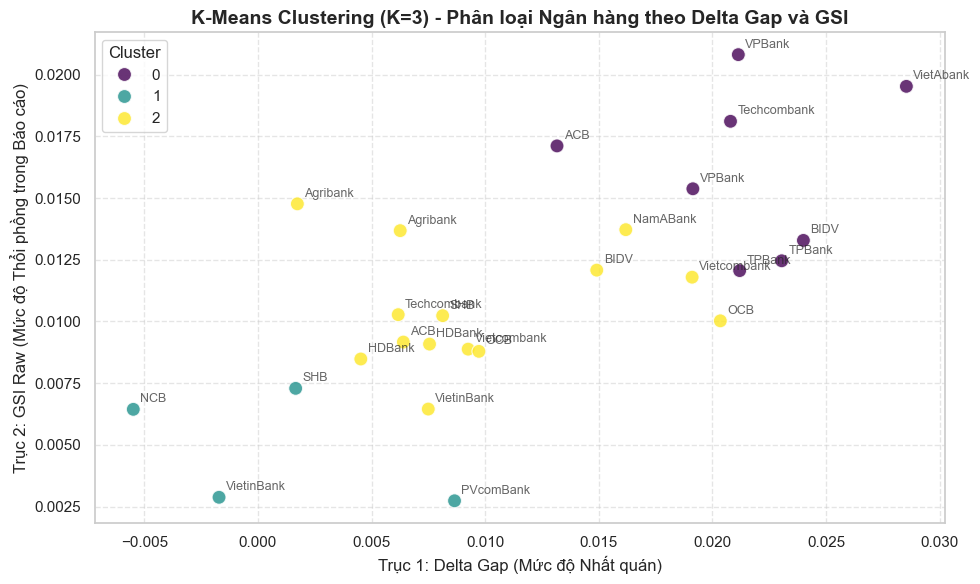

In [5]:
# =====================================================================
# 4. EXPORT KẾT QUẢ & TRỰC QUAN HÓA (VISUALIZATION)
# =====================================================================

# 4.1 Lưu lại file Excel thành phẩm
df_clean.to_excel(OUTPUT_FILE, index=False)
print(f"\n✅ Đã lưu kết quả phân cụm chi tiết tại: {OUTPUT_FILE}")

# 4.2 Vẽ biểu đồ 2D (Scatter Plot) với 2 trục quan trọng nhất là Delta_Gap (Trục 1) và GSI_Raw (Trục 2)
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data=df_clean,
    x='Delta_Gap',
    y='GSI_Raw',
    hue='Cluster',
    palette='viridis', # Màu sắc phân biệt
    s=100,             # Kích thước chấm
    alpha=0.8
)

# Gắn tên ngân hàng vào từng điểm chấm
for i in range(len(df_clean)):
    plt.annotate(
        df_clean['Bank_Name'][i],
        (df_clean['Delta_Gap'][i], df_clean['GSI_Raw'][i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        alpha=0.7
    )

plt.title('K-Means Clustering (K=3) - Phân loại Ngân hàng theo Delta Gap và GSI', fontsize=14, fontweight='bold')
plt.xlabel('Trục 1: Delta Gap (Mức độ Nhất quán)', fontsize=12)
plt.ylabel('Trục 2: GSI Raw (Mức độ Thổi phồng trong Báo cáo)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Lưu hình ảnh
plt.tight_layout()
plt.savefig(PLOT_FILE, dpi=300)
print(f"✅ Đã lưu biểu đồ phân tán tại: {PLOT_FILE}")
plt.show()

✅ Đã lưu biểu đồ PCA phân ranh giới cụm tại: D:\NCKH\Thread_3\PCA_Clustering_Boundaries.png


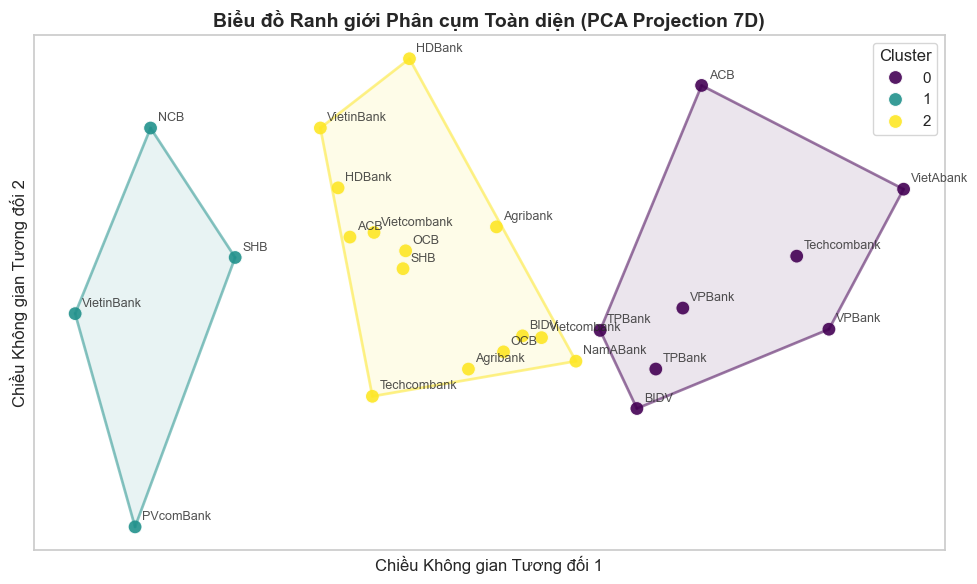

In [7]:
# =====================================================================
# 6. BIỂU ĐỒ PCA BÓC TÁCH CỤM (KHÍCH THƯỚC KHÔNG GIAN 7D -> 2D)
# Biểu đồ này sẽ gộp cả 7 features lại thành một không gian tổng quát
# Không dùng cột X, Y cụ thể nào của dữ liệu để trục tọa độ mang tính tuyệt đối
# =====================================================================
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

# Dùng thuật toán PCA để ép bẹp 7 features xuống thành không gian 2D Ảo
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean['PCA_1'] = X_pca[:, 0]
df_clean['PCA_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))

# Vẽ phân tán các điểm
sns.scatterplot(
    data=df_clean,
    x='PCA_1', 
    y='PCA_2',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.9
)

# Vẽ "Vùng bao quanh" (Convex Hull) để thấy các cụm "đứng cạnh nhau" như thế nào
colors = ['#440154', '#21918c', '#fde725'] # Khớp với palette viridis
for i in range(NUM_CLUSTERS):
    cluster_points = X_pca[cluster_labels == i]
    if len(cluster_points) >= 3: # Cần ít nhất 3 điểm để vẽ đa giác
        hull = ConvexHull(cluster_points)
        # Vẽ đa giác bao quanh cụm
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], color=colors[i], linewidth=2, alpha=0.5)
        plt.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1], color=colors[i], alpha=0.1)

# Gắn tên ngân hàng
for i in range(len(df_clean)):
    plt.annotate(
        df_clean['Bank_Name'][i],
        (df_clean['PCA_1'][i], df_clean['PCA_2'][i]),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        alpha=0.8
    )

# Ẩn hoàn toàn các vạch số trên trục X và Y đi (Đúng yêu cầu không có giá trị x, y)
plt.xticks([])
plt.yticks([])

plt.title('Biểu đồ Ranh giới Phân cụm Toàn diện (PCA Projection 7D)', fontsize=14, fontweight='bold')
plt.xlabel('Chiều Không gian Tương đối 1', fontsize=12)
plt.ylabel('Chiều Không gian Tương đối 2', fontsize=12)

# Lưu hình ảnh
PCA_PLOT_FILE = T3_DIR / "PCA_Clustering_Boundaries.png"
plt.tight_layout()
plt.savefig(PCA_PLOT_FILE, dpi=300)
print(f"✅ Đã lưu biểu đồ PCA phân ranh giới cụm tại: {PCA_PLOT_FILE}")
plt.show()